## Reducer in parallel nodes

Build a task completion system where the progress of a project is tracked through three tasks.

Each task increments the completion percentage of the project: 
    
    Task 1 adds 10%, Task 2 adds 10%, and Task 3 adds 30%. 
    
    The tasks follow a sequential flow where Task 1 starts the process, and Task 2 and Task 3 run in parallel after Task 1.

The state is represented by a list (task_status), and each task updates this list as they are completed.

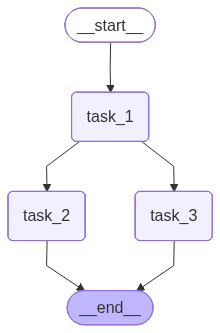

---Task 1---
---Task 2---
---Task 3---


InvalidUpdateError: At key 'task_status': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [11]:
from operator import add
import operator
from typing import Annotated, TypedDict
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Define the State TypedDict
class State(TypedDict):
    task_status:list[int] # List tracking completion percentages of tasks

# Node Functions to update task progress
def task_1(state):
    print("---Task 1---")
    return {"task_status": [state['task_status'][-1] + 10]}

def task_2(state):
    print("---Task 2---")
    return {"task_status": [state['task_status'][-1] + 10]} 

def task_3(state):
    print("---Task 3---")
    return {"task_status": [state['task_status'][-1] + 30]} 

# Build the StateGraph
builder = StateGraph(State)
builder.add_node("task_1", task_1)
builder.add_node("task_2", task_2)
builder.add_node("task_3", task_3)

# Define task sequence (edges)
builder.add_edge(START, "task_1")
builder.add_edge("task_1", "task_2")
builder.add_edge("task_1", "task_3")
builder.add_edge("task_2", END)
builder.add_edge("task_3", END)

# Compile the graph
graph = builder.compile()

# View the graph (it will display a flowchart in a Jupyter notebook)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png())) 

# Start the task with an initial state where task 1 is 0% complete
graph.invoke({"task_status": [0]})


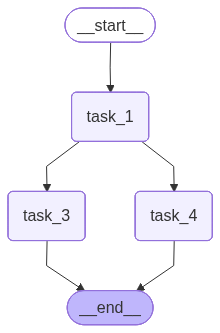

---Task 1---
---Task 3---
---Task 4---


{'task_status': [0, 10, 20, 40]}

In [9]:
from operator import add
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END

# Define the State TypedDict
class State(TypedDict):
    task_status:Annotated[list[int],operator.add] # List tracking completion percentages of tasks

# Node Functions to update task progress
def task_1(state):
    print("---Task 1---")
    return {"task_status": [state['task_status'][-1] + 10]}

def task_3(state):
    print("---Task 3---")
    return {"task_status": [state['task_status'][-1] + 10]} 

def task_4(state):
    print("---Task 4---")
    return {"task_status": [state['task_status'][-1] + 30]} 

# Build the StateGraph
builder = StateGraph(State)
builder.add_node("task_1", task_1)
builder.add_node("task_3", task_3)
builder.add_node("task_4", task_4)

# Define task sequence (edges)
builder.add_edge(START, "task_1")
builder.add_edge("task_1", "task_4")
builder.add_edge("task_1", "task_3")
builder.add_edge("task_4", END)
builder.add_edge("task_3", END)

# Compile the graph
graph = builder.compile()

# View the graph (it will display a flowchart in a Jupyter notebook)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png())) 

# Start the task with an initial state where task 1 is 0% complete
graph.invoke({"task_status": [0]})


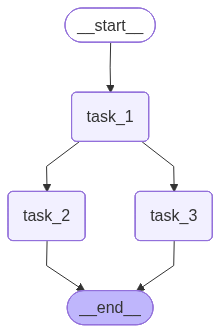

---Task 1---
---Task 2---
---Task 3---


{'task_status': [0, 10, 40, 20]}

In [8]:
from operator import add
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END

# Define the State TypedDict
class State(TypedDict):
    task_status:Annotated[list[int],operator.add] # List tracking completion percentages of tasks

# Node Functions to update task progress
def task_1(state):
    print("---Task 1---")
    return {"task_status": [state['task_status'][-1] + 10]}

def task_3(state):
    print("---Task 3---")
    return {"task_status": [state['task_status'][-1] + 10]} 

def task_2(state):
    print("---Task 2---")
    return {"task_status": [state['task_status'][-1] + 30]} 

# Build the StateGraph
builder = StateGraph(State)
builder.add_node("task_1", task_1)
builder.add_node("task_3", task_3)
builder.add_node("task_2", task_2)

# Define task sequence (edges)
builder.add_edge(START, "task_1")
builder.add_edge("task_1", "task_2")
builder.add_edge("task_1", "task_3")
builder.add_edge("task_2", END)
builder.add_edge("task_3", END)

# Compile the graph
graph = builder.compile()

# View the graph (it will display a flowchart in a Jupyter notebook)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png())) 

# Start the task with an initial state where task 1 is 0% complete
graph.invoke({"task_status": [0]})
